## Beverton-Holt Modell (vgl. Blatt 6, Aufgabe 2, WS)

Nach dem Beverton-Holt-Modell kann das Wachstum einer Population mit beschränktem Lebensraum in diskreten Zeitschritten beschrieben werden durch
$$P_{t+1}=\frac{R}{1+\frac{R-1}{K}P_t}P_t
$$
wobei $R>1$ und $K>0$ Konstanten sind. (Hier ist $t=0,1,…$ der Index der Folge und steht für die diskrete Zeitvariable in dem Modell.) 
Wir wollen im folgenden eine `python`-Funktion schreiben, welche zu gegebenem $P_0, R$ und $K$ die Populationsgrößen nach $P_0,…,P_n$ (auf 2 Nachkommastellen gerundet) als Liste zurückgibt. Wie so etwas funktioniert hast du bereits auf Blatt 4 gelernt:

In [4]:
def bev_holt(P0, R, K, n):
    all_P = [round(P0,2)]
    P_t = P0
    for i in range(n):
        P_t =  R/(1+(R-1)/K*P_t)*P_t
        all_P.append(round(P_t,2))
    return all_P

print(bev_holt(8, 1.4, 20, 10))

[8, 9.66, 11.33, 12.93, 14.38, 15.64, 16.68, 17.51, 18.15, 18.65, 19.01]


Im folgenden wollen wir die Funktion nun etwas erweitern.

### 1. Type des In- und Out-puts deklarieren

Mit dem Doppelpunkt hinter jeder Funktionsvariablen können wir erläutern, welchen Typ diese Variable haben soll. Ebenso können wir mit einem Pfeil `->` angeben, welchen Typ der Output der Funktion hat. Das ist hilfreich für die Anwendung der Funktion, da man so beim Eintippen der Funktion automatisch angezeigt bekommt, für welchen Variablentyp die Funktion geschrieben wurde. Diese Ergänzung dient allerdings nicht zur Überprüfung der Variablen. Wird ein anderer Variablentyp als der notierte eingegeben, kommt es nur zu einer Fehlermeldung, falls die Funktion aus anderen Gründen nicht auf diesen Variablentyp angewendet werden kann.

In [8]:
def bev_holt(P0: float, R:float, K: float, n: int) -> list:
    all_P = [round(P0,2)]
    P_t = P0
    for i in range(n):
        P_t =  R/(1+(R-1)/K*P_t)*P_t
        all_P.append(round(P_t,2))
    return all_P

# Fkt. funktioniert sowohl für float als auch für integer für Wert von K:
print(bev_holt(8, 1.4, 20, 10))
print(bev_holt(8, 1.4, 20.5, 10))

# n darf allerdings kein float sein:
print(bev_holt(8, 1.4, 20, 10.5))

[8, 9.66, 11.33, 12.93, 14.38, 15.64, 16.68, 17.51, 18.15, 18.65, 19.01]
[8, 9.69, 11.41, 13.06, 14.57, 15.89, 16.98, 17.85, 18.54, 19.06, 19.45]


TypeError: 'float' object cannot be interpreted as an integer

### 2. Assertions einbauen

Geben wir für $n$ einen `float` ein, kriegen wir die Fehlermeldung `'float' object cannot be interpreted as an integer`. Das passiert automatisch, da wir die `range()`-Funktion nicht auf Komma-Zahlen anwenden können. Mit dem folgenden Befehl können wir vor dem Ausführen der Funktion abfragen, ob $n$ eine ganze Zahl ist. Das machen wir mit der folgenden Code-Zeile:

`assert isinstance(n, int) and n>=0, f'n muss eine natürliche Zahl sein, eingegeben wurde n={n}'`

`assert` überprüft mit `isinstance(n, int)` ob n vom type int ist (also eine ganze Zahl). Mit `n>=0` wird überprüft ob $n \geq 0$ gilt. Mit `and` legen wir fest, dass *beides* gelten muss. Ist dies nicht der Fall, so wird die Ausgabe nach dem Komma ausgegeben.

Ausserdem wollen wir überprüfen:
- `P0` ist $>0$
- `R` ist $> 1$
- `K` ist $> 1$

Ein Teil der Überprüfungen ist bereits eingebaut. Ergänze die noch fehlenden Überprüfungen.

In [10]:
def bev_holt(P0: float, R:float, K: float, n: int) -> list:
    assert isinstance(n, int) and n >=0, f'n muss eine natürliche Zahl sein, eingegeben wurde n={n}'
    assert P0>0, f'P0 muss größer 0 sein, eingegeben wurde P0={P0}'
    # ÜA: ergänze Überprüfungen für R und K

    all_P = [round(P0,2)]
    P_t = P0
    for i in range(n):
        P_t =  R/(1+(R-1)/K*P_t)*P_t
        all_P.append(round(P_t,2))
    return all_P

# Fehlermeldung falls n keine natürliche Zahl ist:
print(bev_holt(8, 1.4, 20, 10.5))

AssertionError: n muss eine natürliche Zahl sein, eingegeben wurde n=10.5

Überprüfe mit weiteren Code-Zeilen, ob du die restlichen assertions richtig implementiert hast. Achte dabei auf folgendes: Stößt der Code an irgendeiner Stelle auf einen `AssertionError`, wird der Code an dieser Stelle abgebrochen.

In [11]:
## Platz für deinen Code

### 3. Default-Werte setzen

Wir können für Funktionen auch sogenannte default-Werte setzen. Diese dienen dazu, Parameter optional zu machen. Wenn beim Aufruf der Funktion kein Argument für diesen Parameter übergeben wird, verwendet Python automatisch den im Funktionskopf definierten Standardwert.

Dies ist besonders nützlich, um Funktionen flexibler zu gestalten, ohne den Benutzer zu zwingen, jedes Mal alle Details anzugeben. Im folgenden ergänzen wir für unsere Funktion den default-Wert n=10. Wenn wir dann die Funktion `bev_holt(8, 1.4, 20)` aufrufen werden die nächsten 10 Pop.-größen berechnet. Möchtest du jedoch die Pop.-größen für ein anderes n berechnen, funktioniert das genauso wie vorher.

In [13]:
def bev_holt(P0: float, R:float, K: float, n: int=10) -> list:
    assert isinstance(n, int) and n >=0, f'n muss eine natürliche Zahl sein, eingegeben wurde n={n}'
    assert P0>0, f'P0 muss größer 0 sein, eingegeben wurde P0={P0}'
    # ÜA: ergänze Überprüfungen für R und K

    all_P = [round(P0,2)]
    P_t = P0
    for i in range(n):
        P_t =  R/(1+(R-1)/K*P_t)*P_t
        all_P.append(round(P_t,2))
    return all_P

print(bev_holt(8, 1.4, 20))
print(bev_holt(8, 1.4, 20, 10)) # Zur Überprüfung
print(bev_holt(8, 1.4, 20, 8))

[8, 9.66, 11.33, 12.93, 14.38, 15.64, 16.68, 17.51, 18.15, 18.65, 19.01]
[8, 9.66, 11.33, 12.93, 14.38, 15.64, 16.68, 17.51, 18.15, 18.65, 19.01]
[8, 9.66, 11.33, 12.93, 14.38, 15.64, 16.68, 17.51, 18.15]


### Übungsaufgabe

Berechne die Populationsgrößen $P_1,…,P_10$ (auf zwei Stellen gerundet) zu den An-
fangswerten

$P0 = 8$, $P0 = 16$, $P0 = 32$

wobei $K = 20$ und $R = 1.4$. Stelle die Populationsgrößen in einem Plot grafisch dar. Hierfür kannst du dich am Code von `Leslie_Matrix.ipynb` orientieren.

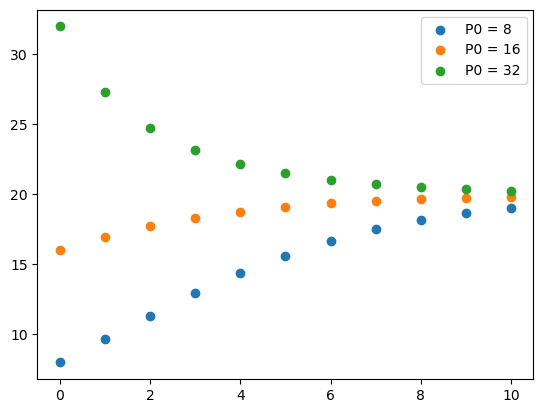

In [14]:
# Lösung

import matplotlib.pyplot as plt

Pop1 = bev_holt(8, 1.4, 20)
Pop2 = bev_holt(16, 1.4, 20)
Pop3 = bev_holt(32, 1.4, 20)

plt.scatter(range(len(Pop1)), Pop1, label='P0 = 8')
plt.scatter(range(len(Pop2)), Pop2, label='P0 = 16')
plt.scatter(range(len(Pop3)), Pop3, label='P0 = 32')
plt.legend()
plt.show()